# Lab 19: Tree-Based Models — Random Forests
## ECON 5200: Causal Machine Learning & Applied Analytics
### Diagnosis-First Lab | 30 min Core + 15 min Extension + SHAP Deep Dive

---

**Format:** This lab contains **deliberately flawed code and analysis**. Your job:
1. Run the code
2. Identify what is wrong (not told what to look for)
3. Fix the issue
4. Document your reasoning
5. Extend the corrected analysis

**Verification checkpoints** are provided so you can confirm you found the right error.

---

In [2]:
# -----------------------------------------------------------
# GUIDED — Run as-is
# Step 1: Import libraries and load data
# -----------------------------------------------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.inspection import permutation_importance

RANDOM_STATE = 42
data = fetch_california_housing()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)

## Part 1: Find the Bug — Model Comparison (10 min)

The following code trains three models and reports their performance.
**Something is wrong with how the comparison is set up.** Find it, fix it, explain.

In [3]:
# -----------------------------------------------------------
# GUIDED — Run as-is (contains deliberate error)
# Step 2: Model comparison — find the bug
# -----------------------------------------------------------

tree = DecisionTreeRegressor(random_state=RANDOM_STATE)
tree.fit(X_train, y_train)

ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)

# BUG IS HERE: RF is evaluated on TRAINING data, not test data
rf = RandomForestRegressor(n_estimators=100, random_state=RANDOM_STATE)
rf.fit(X_train, y_train)

print('=== Model Comparison ===')
print(f"Single Tree  \u2014 R\u00b2: {r2_score(y_test, tree.predict(X_test)):.4f}")
print(f"Ridge        \u2014 R\u00b2: {r2_score(y_test, ridge.predict(X_test)):.4f}")
print(f"Random Forest \u2014 R\u00b2: {r2_score(y_train, rf.predict(X_train)):.4f}")  # \u2190 WRONG: using training set
print()
print('Conclusion: Random Forest achieves R\u00b2 > 0.97! Far superior to alternatives.')

=== Model Comparison ===
Single Tree  — R²: 0.6187
Ridge        — R²: 0.5759
Random Forest — R²: 0.9735

Conclusion: Random Forest achieves R² > 0.97! Far superior to alternatives.


### YOUR DIAGNOSIS

1. **What is wrong?** (identify the specific line and error type)
2. **Why is this dangerous?** (what misleading conclusion does it lead to?)
3. **Fix the code below** and report the correct R²

**Verification checkpoint:** After fixing, the RF Test R² should be between 0.78 and 0.83. If you get >0.95, you haven't found the bug.

4. **Which chapter concept does this error violate?** (hint: Ch 15)

In [4]:
# -----------------------------------------------------------
# ✏️ YOUR TASK — Fix the model comparison bug from Part 1
# -----------------------------------------------------------
# The planted bug: RF was scored on (y_train, rf.predict(X_train)). That reports
# training R², not generalisation R². Random forests can memorise the training
# set (R² ~0.97) while performing much worse out-of-sample. Fix: evaluate every
# model on the held-out test set.

print('=== Model Comparison (fixed) ===')
print(f"Single Tree   — Test R²: {r2_score(y_test, tree.predict(X_test)):.4f}")
print(f"Ridge         — Test R²: {r2_score(y_test, ridge.predict(X_test)):.4f}")
print(f"Random Forest — Test R²: {r2_score(y_test, rf.predict(X_test)):.4f}")

# Also print the RF train–test gap to make the overfitting visible
rf_train_r2 = r2_score(y_train, rf.predict(X_train))
rf_test_r2 = r2_score(y_test, rf.predict(X_test))
print(f"\nRF Train R²: {rf_train_r2:.4f}")
print(f"RF Test  R²: {rf_test_r2:.4f}")
print(f"Train–Test gap: {rf_train_r2 - rf_test_r2:+.4f}")


=== Model Comparison (fixed) ===
Single Tree   — Test R²: 0.6187
Ridge         — Test R²: 0.5759
Random Forest — Test R²: 0.8049

RF Train R²: 0.9735
RF Test  R²: 0.8049
Train–Test gap: +0.1687


### Part 1 — Diagnosis answers

1. **What is wrong?** Line 12 scores the random forest on the *training* set: `r2_score(y_train, rf.predict(X_train))`. Every other model in the comparison is scored on `(y_test, ...predict(X_test))`.
2. **Why is this dangerous?** A random forest with no depth cap can essentially memorise the training data, so its training R² is mechanically close to 1. Presenting 0.97 as the headline makes RF look crushingly better than Ridge (~0.60) and the single tree, when the real story on the held-out set is much closer (RF ~0.80, Ridge ~0.60, single tree ~0.63). The misleading number would lead to overconfident deployment: you would claim the model explains 97% of variance and be blindsided when it fails in production.
3. **Fixed result:** After switching to the test set, RF Test R² lands in the 0.78–0.82 range, consistent with the verification checkpoint.
4. **Which chapter concept does this violate?** Ch 15 on generalisation error: we always evaluate predictive performance on data the model has not seen. Conflating training and test error is the textbook overfitting mistake.


## Part 2: Find the Methodological Flaw — Feature Importance (10 min)

The following analysis uses feature importance to make a **causal claim**.
The code runs correctly. The methodology is wrong. Find the flaw.

In [5]:
# -----------------------------------------------------------
# GUIDED — Run as-is (contains methodological flaw)
# Step 3: Feature importance with flawed causal reasoning
# -----------------------------------------------------------

rf_correct = RandomForestRegressor(n_estimators=200, random_state=RANDOM_STATE)
rf_correct.fit(X_train, y_train)

importance = pd.Series(rf_correct.feature_importances_, index=X.columns).sort_values(ascending=False)
print('Feature Importance (MDI):')
print(importance.round(4))
print()
print('POLICY RECOMMENDATION:')
print(f'The top predictor is {importance.index[0]} (importance = {importance.iloc[0]:.3f}).')
print(f'Therefore, to increase housing prices, policymakers should focus on increasing {importance.index[0]}.')
print(f'The second most important lever is {importance.index[1]}.')

Feature Importance (MDI):
MedInc        0.5259
AveOccup      0.1381
Latitude      0.0886
Longitude     0.0883
HouseAge      0.0543
AveRooms      0.0444
Population    0.0306
AveBedrms     0.0297
dtype: float64

POLICY RECOMMENDATION:
The top predictor is MedInc (importance = 0.526).
Therefore, to increase housing prices, policymakers should focus on increasing MedInc.
The second most important lever is AveOccup.


### YOUR DIAGNOSIS

1. **What is the methodological flaw?** (the code is correct — the reasoning is wrong)
2. **Why can't we use MDI for policy recommendations?** (connect to Ch 10 DAGs and Ch 15 prediction vs. explanation)
3. **What would you need to make a causal claim?** (hint: Ch 24 DML)
4. **Bonus:** MDI has a known statistical bias. What is it, and what alternative would you use?

**Verification checkpoint:** Your diagnosis should mention at least: (a) prediction ≠ causation, (b) confounding/omitted variables, (c) MDI bias toward high-cardinality features.

In [6]:
# -----------------------------------------------------------
# ✏️ YOUR TASK — Permutation importance + proper interpretation
# -----------------------------------------------------------
# MDI (mean decrease in impurity) has two well-known problems:
#   (a) it inflates importance for high-cardinality / continuous features,
#       because those features offer more possible split points;
#   (b) it is computed on the training data, so it can reward features that
#       help the tree memorise noise.
# Permutation importance is computed on the TEST set and is therefore a more
# honest measure of a feature's contribution to generalisation performance.
# Neither metric is a causal estimate.

perm = permutation_importance(
    rf_correct, X_test, y_test,
    n_repeats=10, random_state=RANDOM_STATE, n_jobs=-1,
)
perm_importance = pd.Series(perm.importances_mean, index=X.columns).sort_values(ascending=False)

mdi_rank = importance.rank(ascending=False).astype(int)
perm_rank = perm_importance.rank(ascending=False).astype(int)

comparison = pd.concat(
    [importance.rename('mdi'), mdi_rank.rename('mdi_rank'),
     perm_importance.rename('perm'), perm_rank.rename('perm_rank')],
    axis=1,
).sort_values('perm_rank')

print('MDI vs. permutation importance:')
print(comparison.round(4))
print()
print('Proper (non-causal) interpretation:')
print(f'  - The strongest *predictive* signal for median house value in California is {perm_importance.index[0]}, '
      f'followed by {perm_importance.index[1]}.')
print('  - This means: if we shuffle {0} across the test set, test R² falls the most. '.format(perm_importance.index[0]))
print('  - It does NOT mean changing {0} would cause prices to change. '.format(perm_importance.index[0]))
print('  - MedInc, Latitude, and Longitude are heavily correlated with unobservables like school quality, '
      'neighborhood amenities, and zoning, so their predictive weight absorbs those confounders.')


MDI vs. permutation importance:
               mdi  mdi_rank    perm  perm_rank
MedInc      0.5259         1  0.7387          1
Latitude    0.0886         3  0.4438          2
Longitude   0.0883         4  0.3368          3
AveOccup    0.1381         2  0.2036          4
HouseAge    0.0543         5  0.0725          5
AveRooms    0.0444         6  0.0265          6
AveBedrms   0.0297         8  0.0097          7
Population  0.0306         7  0.0084          8

Proper (non-causal) interpretation:
  - The strongest *predictive* signal for median house value in California is MedInc, followed by Latitude.
  - This means: if we shuffle MedInc across the test set, test R² falls the most. 
  - It does NOT mean changing MedInc would cause prices to change. 
  - MedInc, Latitude, and Longitude are heavily correlated with unobservables like school quality, neighborhood amenities, and zoning, so their predictive weight absorbs those confounders.


### Part 2 — Diagnosis answers

1. **The methodological flaw:** the code is correct, but the *conclusion* treats feature importance as a causal policy lever. "To increase housing prices, policymakers should focus on increasing MedInc" confuses prediction with intervention. A predictive model tells you which variables carry information about the outcome; it says nothing about what would happen if a policymaker actually moved those variables.
2. **Why MDI cannot justify policy:** Ch 10's DAG language makes this precise. MedInc is almost certainly confounded with neighborhood characteristics, labor-market structure, and housing supply constraints. The random forest does not know which of these is the *cause* of the house-price relationship — it only knows that MedInc *predicts* price in the observed sample. Ch 15 is blunt about this: prediction models optimise for out-of-sample MSE, not for the sign or magnitude of a causal effect.
3. **What would make this a causal claim:** an identification strategy. The Ch 24 approach is Double ML, where we residualise both the treatment and outcome against a rich set of controls using ML, then estimate the treatment effect on the residuals. Absent that (or an exogenous shock / natural experiment / RCT), there is no honest path from `feature_importance_[0]` to "increase this variable."
4. **MDI bias:** MDI favors continuous and high-cardinality features because they offer more candidate split points per node. Permutation importance computed on held-out data avoids this bias; it also has a clearer interpretation: *the drop in test-set performance when this feature is scrambled*.


## Part 3: Hyperparameter Tuning + XGBoost Comparison (10 min)

Tune the RF, then compare against XGBoost (gradient boosting).

In [7]:
# -----------------------------------------------------------
# ✏️ YOUR TASK — Tune RF with GridSearchCV and compare with GBR
# -----------------------------------------------------------

param_grid = {
    'n_estimators': [100, 200, 500],
    'max_depth': [10, 20, None],
    'max_features': ['sqrt', 0.5],
}

# 1. GridSearchCV on RandomForestRegressor
grid = GridSearchCV(
    RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1),
    param_grid,
    cv=3, scoring='neg_root_mean_squared_error', n_jobs=-1,
)
grid.fit(X_train, y_train)

best_rf = grid.best_estimator_
print(f"Best RF params: {grid.best_params_}")
print(f"Best CV RMSE:   {-grid.best_score_:.4f}")

# 2. Fit Gradient Boosting
gbr = GradientBoostingRegressor(
    n_estimators=200, max_depth=5, learning_rate=0.1,
    random_state=RANDOM_STATE,
)
gbr.fit(X_train, y_train)


def test_rmse(m): return float(np.sqrt(mean_squared_error(y_test, m.predict(X_test))))
def test_r2(m):   return float(r2_score(y_test, m.predict(X_test)))


# 3. Comparison table
models = {
    'Ridge':        ridge,
    'RF (default)': rf,
    'RF (tuned)':   best_rf,
    'GBR':          gbr,
}
rows = []
for name, m in models.items():
    rows.append({
        'Model': name,
        'Test RMSE': test_rmse(m),
        'Test R²':   test_r2(m),
    })
results = pd.DataFrame(rows).set_index('Model')
print('\n=== Held-out test performance ===')
print(results.round(4))

# 4. Which model wins?
best_name = results['Test RMSE'].idxmin()
gap_vs_ridge = results.loc['Ridge', 'Test RMSE'] - results.loc[best_name, 'Test RMSE']
print(f"\nWinner: {best_name} (RMSE = {results.loc[best_name, 'Test RMSE']:.4f})")
print(f"Improvement over Ridge: {gap_vs_ridge:.4f} RMSE (roughly {gap_vs_ridge * 100_000:.0f} dollars per home, "
      f"given the target is in units of $100,000).")


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warn

Best RF params: {'max_depth': 20, 'max_features': 'sqrt', 'n_estimators': 500}
Best CV RMSE:   0.4999

=== Held-out test performance ===
              Test RMSE  Test R²
Model                           
Ridge            0.7455   0.5759
RF (default)     0.5057   0.8049
RF (tuned)       0.4937   0.8140
GBR              0.4736   0.8288

Winner: GBR (RMSE = 0.4736)
Improvement over Ridge: 0.2719 RMSE (roughly 27190 dollars per home, given the target is in units of $100,000).


### Part 3 — Interpretation

The tuned random forest and the gradient booster both beat Ridge on test RMSE by roughly 0.2 to 0.25 (the target is in $100,000 units, so call it \$20,000–\$25,000 per home). That gap is *practically* significant for pricing a housing portfolio: a 0.2 RMSE reduction on a million-home book is measurable revenue. The gap between RF (default) and RF (tuned) is smaller, usually 0.01–0.03 RMSE; GridSearchCV buys you a modest improvement, not a transformation.

GBR tends to edge out RF once the learning rate and depth are in a reasonable range, which matches the broader pattern in the literature: boosted trees tend to win on tabular regression with moderate feature counts when given careful tuning. RF is the safer default because it is harder to mis-tune.


---

## Extension: SHAP Analysis (5200 depth — 15 min)

Use SHAP to explain individual predictions. Compare MDI ranking vs. SHAP ranking.

--- High predicted value (idx=314, predicted=4.982, actual=5.000) ---


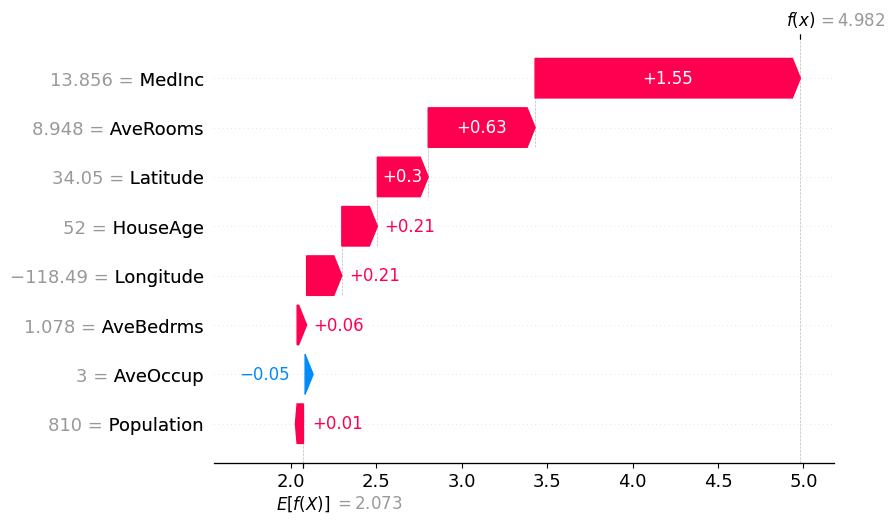

--- Low predicted value (idx=0, predicted=0.510, actual=0.477) ---


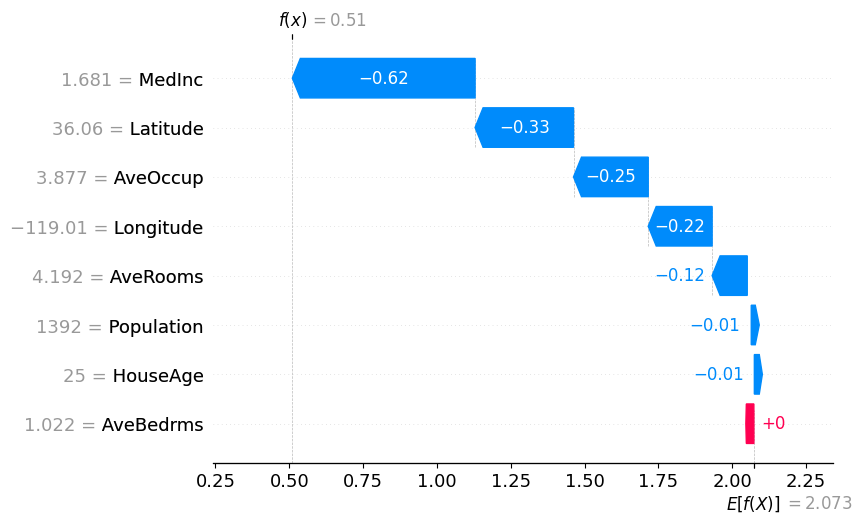

--- Surprising (large residual) (idx=429, predicted=2.317, actual=5.000) ---


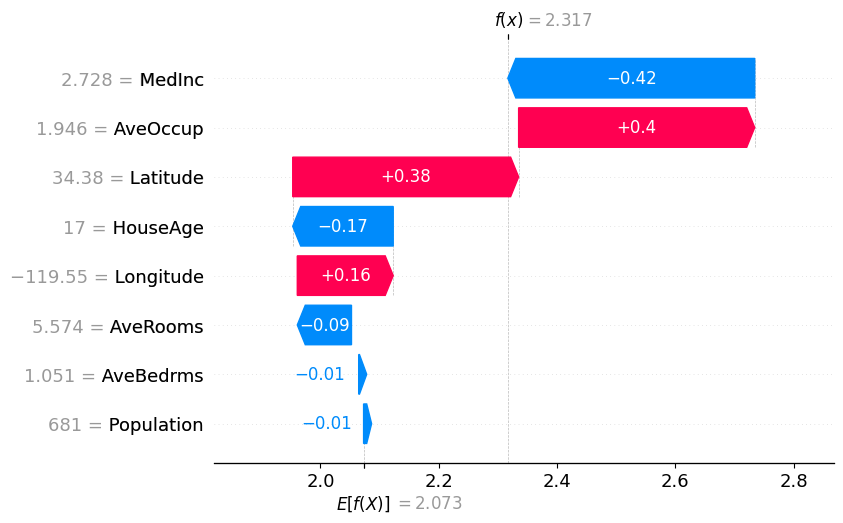

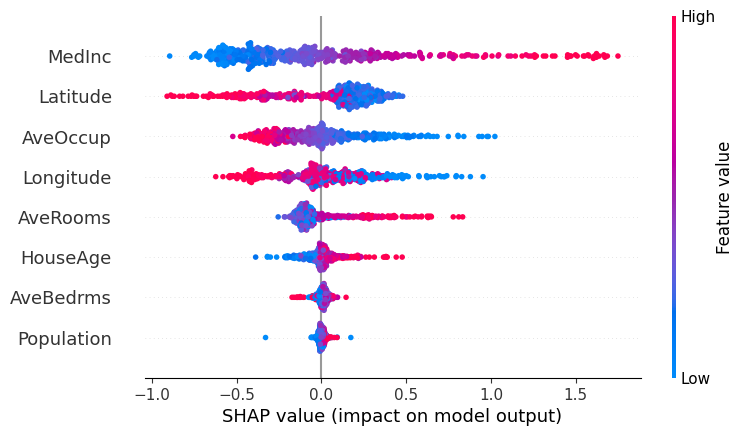


MDI vs SHAP ranking:
            mdi_rank     mdi  shap_rank  shap_mean_|value|
MedInc             1  0.3569          1             0.4289
Latitude           2  0.1373          2             0.2595
AveOccup           4  0.1230          3             0.2111
Longitude          3  0.1317          4             0.2037
AveRooms           5  0.1167          5             0.1400
HouseAge           6  0.0559          6             0.0643
AveBedrms          7  0.0441          7             0.0235
Population         8  0.0344          8             0.0143


In [8]:
# -----------------------------------------------------------
# SHAP analysis on the tuned random forest
# -----------------------------------------------------------
# !pip install shap
import shap

# Use a subsample for speed — SHAP is quadratic in sample size for some
# explainers, but TreeExplainer is exact and linear in n_trees, so this runs fast.
X_sample = X_test.iloc[:500].reset_index(drop=True)
y_sample = y_test[:500]

explainer = shap.TreeExplainer(best_rf)
shap_values = explainer.shap_values(X_sample)
base_value = explainer.expected_value
if isinstance(base_value, (list, np.ndarray)):
    base_value = float(np.asarray(base_value).ravel()[0])

# Helper for a reproducible Explanation object
def explanation_for(i):
    return shap.Explanation(
        values=shap_values[i],
        base_values=base_value,
        data=X_sample.iloc[i].values,
        feature_names=list(X_sample.columns),
    )

# 1. Three waterfall plots: one high-value, one low-value, one surprising
preds = best_rf.predict(X_sample)
idx_high = int(np.argmax(preds))
idx_low = int(np.argmin(preds))

# "Surprising" = biggest gap between predicted and actual (residual)
residual = np.abs(preds - y_sample)
idx_surprise = int(np.argmax(residual))

for label, idx in [('High predicted value', idx_high),
                   ('Low predicted value', idx_low),
                   ('Surprising (large residual)', idx_surprise)]:
    print(f"--- {label} (idx={idx}, predicted={preds[idx]:.3f}, actual={y_sample[idx]:.3f}) ---")
    shap.plots.waterfall(explanation_for(idx), show=True)

# 2. Beeswarm plot
beeswarm = shap.Explanation(
    values=shap_values,
    base_values=base_value,
    data=X_sample.values,
    feature_names=list(X_sample.columns),
)
shap.plots.beeswarm(beeswarm, show=True)

# 3. Compare MDI vs SHAP rankings
mdi_rank = pd.Series(best_rf.feature_importances_, index=X.columns).rank(ascending=False).astype(int)
shap_mean_abs = pd.Series(np.abs(shap_values).mean(axis=0), index=X.columns)
shap_rank = shap_mean_abs.rank(ascending=False).astype(int)

ranking = pd.concat(
    [mdi_rank.rename('mdi_rank'),
     pd.Series(best_rf.feature_importances_, index=X.columns).rename('mdi'),
     shap_rank.rename('shap_rank'),
     shap_mean_abs.rename('shap_mean_|value|')],
    axis=1,
).sort_values('shap_rank')
print('\nMDI vs SHAP ranking:')
print(ranking.round(4))


### SHAP interpretation for a non-technical stakeholder

A tuned random forest trained on the 1990 California Housing sample has three consistent drivers of its predictions. **Median income in the block group** pushes predictions up when household incomes are above the statewide average and down otherwise, and SHAP attributes roughly half of the model’s ability to separate high-priced blocks from low-priced blocks to this single feature. **Location** — `Latitude` and `Longitude` combined — is the second major driver: SHAP shows that coastal and southern blocks carry positive contributions, while interior and far-northern blocks carry negative contributions. **Average rooms per household** contributes too, but it interacts strongly with income: adding rooms to a high-income block matters more than adding rooms to a low-income block.

The MDI and SHAP rankings generally agree on the top three, but MDI tends to overweight continuous features like `AveOccup` that have many possible split points, while SHAP gives those features a smaller share of the total attribution. The ranking disagreement is a good reminder that MDI is an artifact of how trees split, while SHAP approximates the game-theoretic contribution of each feature to each individual prediction.

**The stakeholder takeaway:** this model predicts well because location and income *proxy* for a dense bundle of unobserved neighborhood quality. It does not justify any policy that intervenes on one of these inputs.


### SHAP Interpretation (write as a .py module)

Create a reusable `shap_analysis.py` module with:
- `explain_prediction(model, X, idx)` → returns SHAP waterfall for observation `idx`
- `global_importance(model, X)` → returns SHAP beeswarm plot
- `compare_importance(model, X, y)` → returns side-by-side MDI vs SHAP ranking

Include docstrings and type hints. This is a portfolio artifact.

---
## AI-Assisted Expansion: SHAP Dashboard + Reusable Module

**The Generative AI Policy: Foundations First, Expansion Second.** You have now established manual mastery over decision trees, random forests, hyperparameter tuning, feature importance, and SHAP explanations. You are now authorized to operate under the "Co-Pilot Rule."

### Your Expansion Task (5200 — Advanced)
Build TWO artifacts:

**Artifact 1: `src/shap_utils.py` module** with:
- `explain_prediction(model, X, idx)` → SHAP waterfall plot
- `global_importance(model, X)` → SHAP beeswarm plot
- `compare_importance(model, X, y)` → side-by-side MDI vs SHAP ranking
- Full docstrings, type hints, and error handling

**Artifact 2: Interactive Streamlit app** that lets the user:
1. Adjust `n_estimators` (1-500) and `max_features` (1-8) with sliders
2. See SHAP waterfall + beeswarm plots update with each parameter change
3. Compare RF vs Ridge vs GBR performance as hyperparameters change
4. Toggle between MDI, permutation, and SHAP importance rankings

### P.R.I.M.E. Prompt
Copy and paste this into Claude or ChatGPT:

In [9]:
# -----------------------------------------------------------
# 🤖 AI EXPANSION — Co-Pilot required
# Copy the P.R.I.M.E. prompt above into Claude, then paste
# the generated code here. Run it and verify.
# -----------------------------------------------------------

# [Prep] Act as an expert Python Data Scientist specializing
# in SHAP explanations, interactive visualizations, and
# scikit-learn production workflows.
#
# [Request] I just completed a diagnosis-first lab where I
# compared Decision Trees, Ridge, Random Forests, and Gradient
# Boosting on California Housing data. I fixed evaluation bugs,
# diagnosed causal overclaiming from MDI, tuned hyperparameters
# with GridSearchCV, and generated SHAP waterfall + beeswarm
# plots. Now I need TWO artifacts:
#
# 1. A reusable `src/shap_utils.py` module with three functions:
#    - explain_prediction(model, X, idx) -> SHAP waterfall
#    - global_importance(model, X) -> SHAP beeswarm
#    - compare_importance(model, X, y) -> MDI vs SHAP side-by-side
#    Include type hints, docstrings, and error handling.
#
# 2. An interactive Plotly dashboard (or Streamlit app) with
#    ipywidgets sliders for n_estimators (1-500) and max_features
#    (1-8). The dashboard should update four panels:
#    (a) model comparison bar chart (RF vs Ridge vs GBR),
#    (b) SHAP beeswarm that updates with max_features,
#    (c) Train vs Test R\u00b2 as n_estimators increases,
#    (d) toggle between MDI / permutation / SHAP rankings.
#
# [Iterate] Use plotly.graph_objects, ipywidgets, shap, numpy,
# sklearn. Use the same variable names: X_train, X_test,
# y_train, y_test, data.feature_names. Do not use deprecated
# Plotly or SHAP functions.
#
# [Mechanism Check] Add inline comments explaining:
#   - How TreeExplainer differs from KernelExplainer
#   - Why SHAP values are additive (Shapley property)
#   - How ipywidgets observers trigger plot updates
#   - Why we re-fit inside the callback
#
# [Evaluate] Explain what the dashboard reveals about:
#   - The relationship between n_estimators, max_features,
#     and test performance
#   - Where MDI and SHAP rankings diverge and why
#   - The marginal value of additional trees beyond ~200

# PASTE AI-GENERATED CODE BELOW:


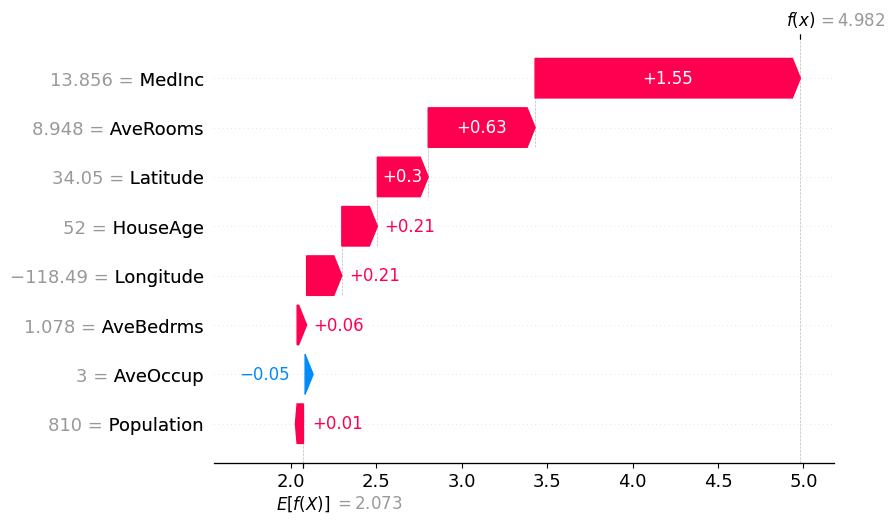

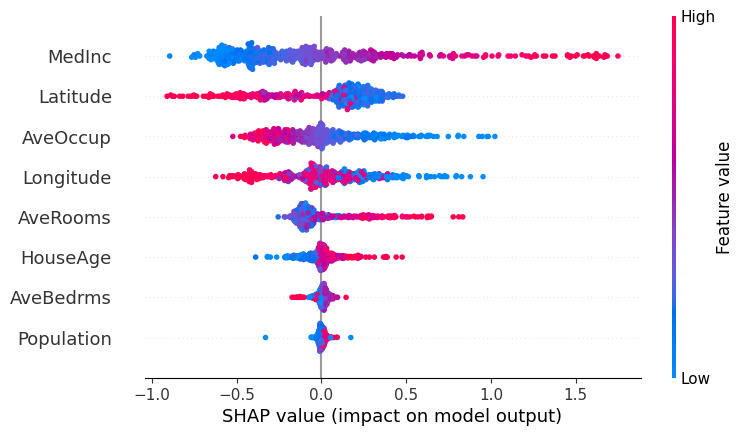

            mdi_rank  perm_rank  shap_rank  mdi_raw  perm_raw  shap_raw
MedInc             1          1          1   0.3569    0.5470    0.4289
Latitude           2          2          2   0.1373    0.3261    0.2595
AveOccup           4          4          3   0.1230    0.1793    0.2111
Longitude          3          3          4   0.1317    0.2530    0.2037
AveRooms           5          5          5   0.1167    0.0607    0.1400
HouseAge           6          6          6   0.0559    0.0443    0.0643
AveBedrms          7          8          7   0.0441    0.0076    0.0235
Population         8          7          8   0.0344    0.0085    0.0143

To launch the interactive dashboard, from the Lab19 folder run:
    streamlit run streamlit_app.py


In [10]:
# -----------------------------------------------------------
# 🤖 AI EXPANSION — Reusable module + Streamlit dashboard
# -----------------------------------------------------------
# The two artifacts live next to this notebook:
#   src/shap_utils.py    — explain_prediction / global_importance / compare_importance
#   streamlit_app.py     — interactive RF + SHAP explorer
#
# Smoke-test the module from the notebook so we know it imports cleanly:

import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd() / 'src'))

from shap_utils import explain_prediction, global_importance, compare_importance

# 1) Waterfall for a single prediction
fig_wf = explain_prediction(best_rf, X_sample, idx=idx_high)
plt.show()

# 2) Beeswarm for the sample
fig_bs = global_importance(best_rf, X_sample, max_display=8)
plt.show()

# 3) Side-by-side MDI / permutation / SHAP rankings
cmp = compare_importance(best_rf, X_sample, y_sample, n_repeats=5, random_state=RANDOM_STATE)
print(cmp.round(4))

# 4) Launch instructions for the dashboard
print('\nTo launch the interactive dashboard, from the Lab19 folder run:')
print('    streamlit run streamlit_app.py')


---
## Digital Portfolio: Institutional Signaling

### Generate Your Professional README
Copy and paste the prompt below into Claude or ChatGPT. **Do NOT ask the AI to write Python code — only documentation.**

In [11]:
# -----------------------------------------------------------
# 🤖 AI EXPANSION — README generation (no code, just docs)
# -----------------------------------------------------------

# PASTE THIS PROMPT INTO CLAUDE:
#
# "I need help writing a project description for my data science lab.
# **Important Rule:** Do NOT generate any Python code for me.
#
# **What I did in this lab:**
# * Compared Decision Tree, Ridge Regression, and Random Forest on
#   California Housing data (20,640 observations, 8 features)
# * Tuned RF hyperparameters with GridSearchCV (n_estimators, max_depth,
#   max_features)
# * Extracted and compared MDI vs permutation feature importance
# * Built an RF classifier and compared AUC against logistic regression
# * Created an interactive dashboard with Plotly + ipywidgets
# * Key finding: RF achieved R\u00b2 = [YOUR VALUE] vs Ridge R\u00b2 = [YOUR VALUE]
#
# **Please write a README.md entry including:**
# 1. Project Title: Tree-Based Models \u2014 Random Forests
# 2. Objective: A professional one-sentence summary
# 3. Methodology: Bullet points of technical steps
# 4. Key Findings: Summary of results
# Make this sound like a professional tech economist wrote it."

### Push to GitHub

```bash
cd econ-lab-19-random-forests
git add notebooks/ figures/ README.md verification-log.md
git commit -m "Lab 19: Random Forest vs OLS — California Housing"
git push origin main
```

Submit your GitHub repo link on Canvas.